
# **DL Lab 12: 16th Oct, 2025**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**




In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional, Embedding
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# **Question 1 & 2**

In [4]:
df = pd.read_csv("/content/gold_price.csv")
print("Columns:", df.columns.tolist())
display(df.head())

Columns: ['Date', 'Price']


,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93


In [5]:
price_col = None
candidates = ['Price', 'price', 'Gold_Price', 'gold_price', 'Close', 'close', 'Adj Close', 'Adj_Close']
for c in candidates:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError("No numeric column found in the uploaded CSV; please provide gold price numeric column.")
    price_col = numeric_cols[0]
print("Using price column:", price_col)

prices = df[price_col].astype(float).values.reshape(-1, 1)

Using price column: Price


In [6]:
WINDOW = 10
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(prices_scaled, WINDOW)
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (2301, 10, 1) y shape: (2301, 1)


In [7]:
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])

Train samples: 1840 Test samples: 461


In [8]:
def build_simple_rnn(input_shape):
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_bigru(input_shape):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=False), input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [9]:
input_shape = (WINDOW, 1)
models = {
    "SimpleRNN": build_simple_rnn(input_shape),
    "BiLSTM": build_bilstm(input_shape),
    "BiGRU": build_bigru(input_shape)
}

for name, m in models.items():
    print(f"\n{name} summary:")
    m.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



SimpleRNN summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,889 (116.75 KB)

 Trainable params: 29,889 (116.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 100
BATCH = 32
histories = {}
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

for name, model in models.items():
    print(f"\nTraining {name} ...")
    history = model.fit(X_train, y_train,
                        validation_split=0.1,
                        epochs=EPOCHS,
                        batch_size=BATCH,
                        callbacks=[es],
                        verbose=2)
    histories[name] = history


Training SimpleRNN ...
Epoch 1/100
52/52 - 4s - 82ms/step - loss: 1.1995e-05 - mae: 0.0017 - val_loss: 0.0016 - val_mae: 0.0280
Epoch 2/100
52/52 - 0s - 4ms/step - loss: 8.0572e-08 - mae: 1.9752e-04 - val_loss: 0.0016 - val_mae: 0.0277
Epoch 3/100
52/52 - 0s - 4ms/step - loss: 9.9242e-08 - mae: 2.3296e-04 - val_loss: 0.0016 - val_mae: 0.0283
Epoch 4/100
52/52 - 0s - 4ms/step - loss: 1.3481e-07 - mae: 2.8549e-04 - val_loss: 0.0017 - val_mae: 0.0288
Epoch 5/100
52/52 - 0s - 5ms/step - loss: 1.3830e-07 - mae: 2.8662e-04 - val_loss: 0.0017 - val_mae: 0.0286
Epoch 6/100
52/52 - 0s - 4ms/step - loss: 1.7983e-07 - mae: 3.4905e-04 - val_loss: 0.0018 - val_mae: 0.0301
Epoch 7/100
52/52 - 0s - 4ms/step - loss: 2.1540e-07 - mae: 3.7851e-04 - val_loss: 0.0019 - val_mae: 0.0311
Epoch 8/100
52/52 - 0s - 5ms/step - loss: 1.3822e-07 - mae: 2.8947e-04 - val_loss: 0.0020 - val_mae: 0.0318
Epoch 9/100
52/52 - 0s - 5ms/step - loss: 9.7870e-08 - mae: 2.2187e-04 - val_loss: 0.0021 - val_mae: 0.0328
Epoch 1

In [11]:
results = []
predictions = {}
for name, model in models.items():
    pred_scaled = model.predict(X_test)
    pred = scaler.inverse_transform(pred_scaled)
    true = scaler.inverse_transform(y_test)
    rmse = mean_squared_error(true, pred,)
    mae = mean_absolute_error(true, pred)
    results.append({"Model": name, "RMSE": float(rmse), "MAE": float(mae)})
    predictions[name] = {"pred": pred.flatten(), "true": true.flatten()}

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,Model,RMSE,MAE
0,BiLSTM,184325.813916,302.218928
1,SimpleRNN,593613.190631,570.150687
2,BiGRU,631378.563504,566.225759


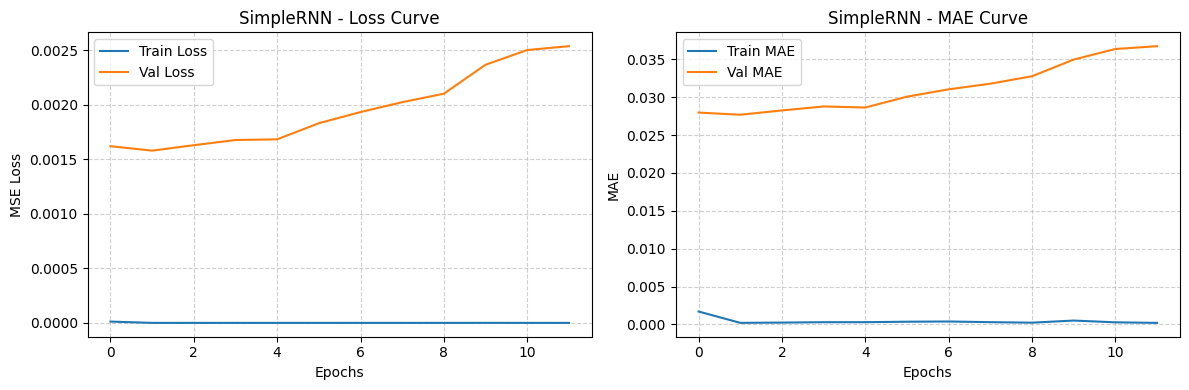

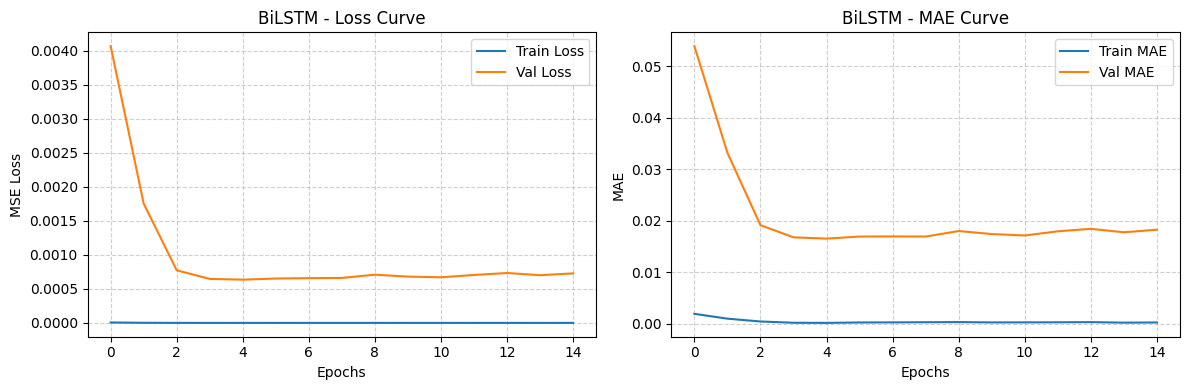

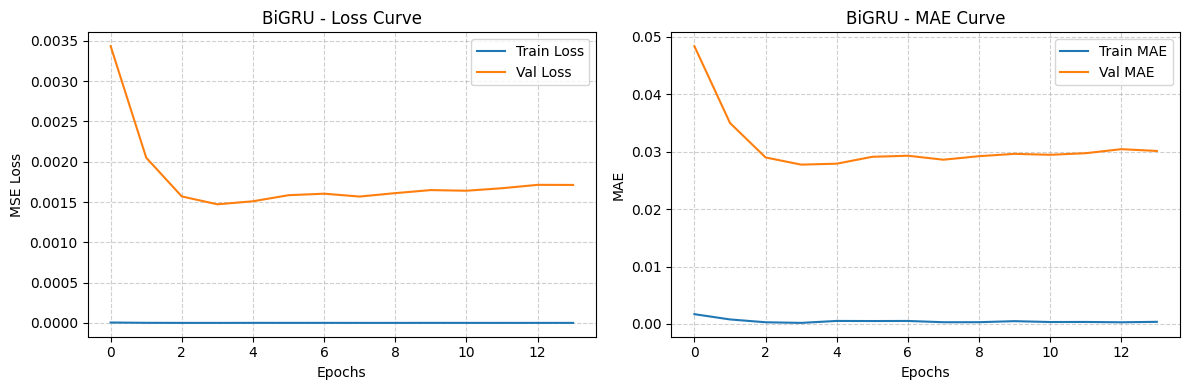

In [12]:
for name, history in histories.items():
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1,2,2)
    if 'mae' in history.history:
        plt.plot(history.history['mae'], label='Train MAE')
        plt.plot(history.history['val_mae'], label='Val MAE')
    else:
        metric_key = list(history.history.keys())[1]
        plt.plot(history.history[metric_key], label=f'Train {metric_key}')
        plt.plot(history.history[f'val_{metric_key}'], label=f'Val {metric_key}')
    plt.title(f'{name} - MAE Curve')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# **Question 3**

In [13]:
VOCAB_SIZE = 5000
WINDOW_WORDS = 10

# load tokenized imdb
(x_train_raw, _), (x_test_raw, _) = imdb.load_data(num_words=VOCAB_SIZE)
# Use a subset for speed
all_seqs = np.concatenate([x_train_raw[:5000], x_test_raw[:1000]])

def make_word_sequences(seqs, window=WINDOW_WORDS, vocab_size=VOCAB_SIZE):
    Xs, ys = [], []
    for seq in seqs:
        if len(seq) <= window:
            continue
        for i in range(len(seq)-window):
            Xs.append(seq[i:i+window])
            ys.append(seq[i+window])
    Xs = pad_sequences(Xs, maxlen=window, padding='pre')
    ys = np.array(ys)
    ys = np.where(ys < vocab_size, ys, 2)  # OOV -> index 2 (<UNK>)
    return np.array(Xs), np.array(ys)

Xw, yw = make_word_sequences(all_seqs, window=WINDOW_WORDS)
print("Word sequences prepared:", Xw.shape, yw.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Word sequences prepared: (1390317, 10) (1390317,)


In [14]:
embedding_dim = 64
model_word = Sequential([
    Embedding(VOCAB_SIZE, embedding_dim, input_length=WINDOW_WORDS),
    SimpleRNN(128),
    Dense(VOCAB_SIZE, activation='softmax')
])
model_word.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_word.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
es_word = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
hist_word = model_word.fit(Xw, yw, validation_split=0.1, epochs=5, batch_size=256, callbacks=[es_word], verbose=1)

Epoch 1/5
4888/4888 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.1376 - loss: 5.6868 - val_accuracy: 0.1727 - val_loss: 5.0705
Epoch 2/5
4888/4888 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.1825 - loss: 4.9743 - val_accuracy: 0.1833 - val_loss: 4.9306
Epoch 3/5
4888/4888 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.1925 - loss: 4.8100 - val_accuracy: 0.1881 - val_loss: 4.8788
Epoch 4/5
4888/4888 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.1980 - loss: 4.7044 - val_accuracy: 0.1903 - val_loss: 4.8509
Epoch 5/5
4888/4888 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.2012 - loss: 4.6326 - val_accuracy: 0.1917 - val_loss: 4.8434
Restoring model weights from the end of the best epoch: 5.



Evaluating next-word RNN model on training and validation data:
Final Training Loss: 4.6541
Final Validation Loss: 4.8434
Final Training Accuracy: 0.2010
Final Validation Accuracy: 0.1917


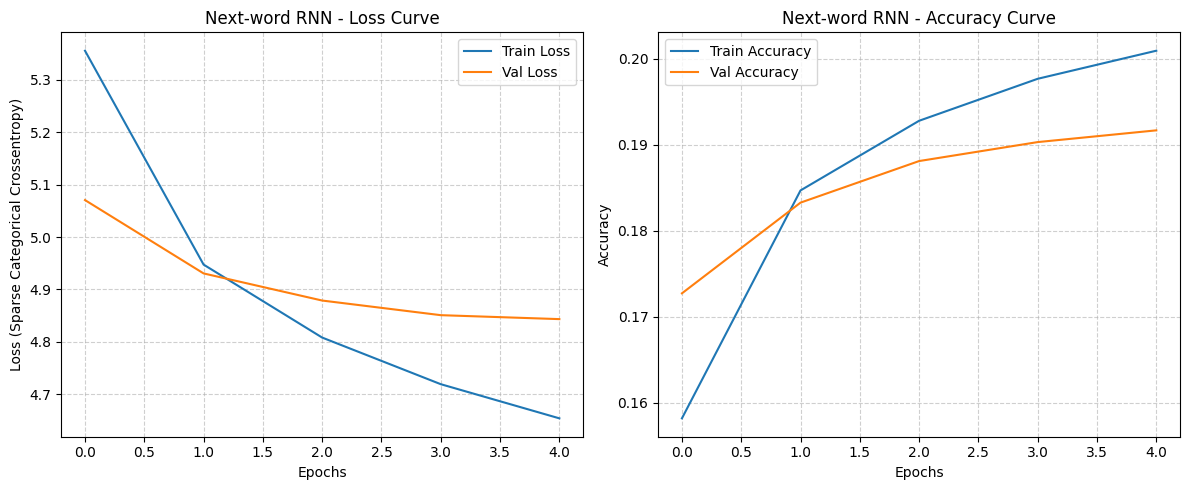

In [16]:
print("\nEvaluating next-word RNN model on training and validation data:")


train_loss = hist_word.history['loss'][-1]
val_loss = hist_word.history['val_loss'][-1]
train_acc = hist_word.history['accuracy'][-1]
val_acc = hist_word.history['val_accuracy'][-1]

print(f"Final Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(hist_word.history['loss'], label='Train Loss')
plt.plot(hist_word.history['val_loss'], label='Val Loss')
plt.title("Next-word RNN - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (Sparse Categorical Crossentropy)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1,2,2)
plt.plot(hist_word.history['accuracy'], label='Train Accuracy')
plt.plot(hist_word.history['val_accuracy'], label='Val Accuracy')
plt.title("Next-word RNN - Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()